<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/AdClickPredCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import requests
import io
from imblearn.over_sampling import SMOTE

In [56]:
# fuzzy to let colab extract filenmae from the link and save it in the colab files
!gdown --fuzzy --output Ad_Click_prediction_train.csv https://drive.google.com/file/d/1eiZkHD5L41lsbpbLXTA2BP7afOt9Z5Nw/view?usp=drive_link
!gdown --fuzzy --output Ad_Click_prediction_test.csv https://drive.google.com/file/d/1eeXHpL_6WYxfTYf6Z0S7WsSxhOt3cK4W/view?usp=drive_link

Downloading...
From: https://drive.google.com/uc?id=1eiZkHD5L41lsbpbLXTA2BP7afOt9Z5Nw
To: /content/Ad_Click_prediction_train.csv
100% 34.3M/34.3M [00:00<00:00, 67.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eeXHpL_6WYxfTYf6Z0S7WsSxhOt3cK4W
To: /content/Ad_Click_prediction_test.csv
100% 9.47M/9.47M [00:00<00:00, 42.8MB/s]


In [57]:
data = pd.read_csv("/content/Ad_Click_prediction_train.csv")
test_data = pd.read_csv("/content/Ad_Click_prediction_test.csv")
data

,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520,13787,4,NaN,10.0,Female,4.0,3.0,3.0,0,0
1,333291,2017-07-02 00:00,243253,C,105960,11085,5,NaN,8.0,Female,2.0,2.0,NaN,0,0
2,129781,2017-07-02 00:00,243253,C,359520,13787,4,NaN,8.0,Female,2.0,2.0,NaN,0,0
3,464848,2017-07-02 00:00,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,3.0,2.0,1,0
4,90569,2017-07-02 00:01,663656,C,405490,60305,3,NaN,2.0,Male,2.0,3.0,2.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463286,583588,2017-07-07 23:59,572718,H,118601,28529,5,82527.0,4.0,Male,4.0,3.0,2.0,0,0
463287,198389,2017-07-07 23:59,130461,I,118601,28529,4,82527.0,10.0,Female,4.0,3.0,2.0,1,0
463288,563423,2017-07-07 23:59,306241,D,118601,28529,4,82527.0,2.0,Male,2.0,3.0,NaN,0,0
463289,595571,2017-07-07 23:59,306241,D,118601,28529,5,82527.0,2.0,Male,2.0,3.0,NaN,0,0


In [58]:
#cleaning column names
def column_name_cleaning(df):
  df.columns=df.columns.str.strip()
  df.columns=df.columns.str.lower()
  return df

In [59]:
data=column_name_cleaning(data)
test_data=column_name_cleaning(test_data)

In [60]:
data.describe()

,session_id,user_id,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,age_level,user_depth,city_development_index,var_1,is_click
count,463291.000000,4.632910e+05,463291.000000,463291.000000,463291.000000,97437.000000,445048.000000,445048.000000,445048.000000,338162.000000,463291.000000,463291.000000
mean,285544.090725,5.460497e+05,308474.540069,29685.878994,3.072427,162753.345105,3.477396,2.782266,2.878415,2.557121,0.422169,0.067627
std,168577.345887,3.294625e+05,126517.101294,21542.053106,1.304233,78743.742720,2.412889,1.069701,0.400130,0.921345,0.493906,0.251105
min,2.000000,4.000000e+00,82320.000000,1734.000000,1.000000,18595.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,137856.500000,2.578550e+05,118601.000000,13787.000000,2.000000,82527.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,285429.000000,5.318010e+05,359520.000000,13787.000000,3.000000,146115.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
75%,435535.500000,8.278490e+05,405490.000000,53587.000000,4.000000,254132.000000,4.000000,3.000000,3.000000,3.000000,1.000000,0.000000
max,595812.000000,1.141729e+06,414149.000000,60305.000000,5.000000,450184.000000,12.000000,6.000000,3.000000,4.000000,1.000000,1.000000


In [61]:
# printing uinique values in each column
for x in data.columns:
  if data[x].nunique()<30:  # using 30 values as threshold to split columns as categorical and numerical
    print(f"Column {x} has {data[x].nunique()} unique values:")
    print(data[x].unique())
  else:
    print(f"Column {x} has {data[x].nunique()} unique values")
  print()

Column session_id has 463291 unique values

Column datetime has 8610 unique values

Column user_id has 150347 unique values

Column product has 10 unique values:
['C' 'I' 'F' 'H' 'B' 'D' 'G' 'E' 'J' 'A']

Column campaign_id has 10 unique values:
[359520 105960 405490 360936 404347  98970 414149  82320 396664 118601]

Column webpage_id has 9 unique values:
[13787 11085 60305 53587  6970 45962  1734 51181 28529]

Column product_category_1 has 5 unique values:
[4 5 3 2 1]

Column product_category_2 has 29 unique values:
[    nan 270915. 146115. 254132. 372532. 450184.  18595. 255689. 408790.
 202351. 408831.  32026. 235358. 143597. 234846. 301147.  99226. 419804.
 269093. 270147. 181650.  66101. 419304. 300711. 447834.  82527. 327439.
 381435. 168114. 247789.]

Column user_group_id has 13 unique values:
[10.  8.  3.  2.  1.  9.  4. nan 11.  7.  5. 12.  6.  0.]

Column gender has 2 unique values:
['Female' 'Male' nan]

Column age_level has 7 unique values:
[ 4.  2.  3.  1. nan  5.  6.  0.]

In [62]:
# function to split columns as cat and numerical columns
def find_cat_num_cols(df):
  # cat_cols=list(df.select_dtypes(include="object").columns)
  # num_cols=list(df.select_dtypes(exclude="object").columns)
  cat_cols=[]
  num_cols=[]
  for x in data.columns:
    if data[x].nunique()<10:
      cat_cols.append(x)
    else:
      num_cols.append(x)
  return cat_cols, num_cols

In [63]:
# finding nulls in each column
data.isna().sum()

,0
session_id,0
datetime,0
user_id,0
product,0
campaign_id,0
webpage_id,0
product_category_1,0
product_category_2,365854
user_group_id,18243
gender,18243


In [64]:
data['session_id'].nunique()  # all rows are unique, no duplicates

463291

In [65]:
# funciton to count clicks in the data set
def class_counter(df, col):
  cc = df[col].value_counts(dropna=False)
  return cc

In [66]:
print("Click counts")
class_counts = class_counter(data,'is_click')
class_counts

Click counts


,count
is_click,
0,431960
1,31331


In [67]:
# total click rate calculation
ctr=float(100*class_counts[1]/(class_counts[0]+class_counts[1]))
print("Click Through Rate =",ctr)

Click Through Rate = 6.762704218299082


In [68]:
data['datetime']=pd.to_datetime(data['datetime'])
test_data['datetime']=pd.to_datetime(test_data['datetime'])

In [69]:
data['year']=data['datetime'].dt.year
data['month']=data['datetime'].dt.month
data['day']=data['datetime'].dt.day
data['hour']=data['datetime'].dt.hour

test_data['year']=test_data['datetime'].dt.year
test_data['month']=test_data['datetime'].dt.month
test_data['day']=test_data['datetime'].dt.day
test_data['hour']=test_data['datetime'].dt.hour

print(data['year'].unique())
print(data['month'].unique())
print(data['day'].unique())
print(data['hour'].unique())

[2017]
[7]
[2 3 4 5 6 7]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


#### Year, month have no correlation with any column since, they have constant values, year=2017 and month=07. So removing them.

In [70]:
# remove datetime, year, month columns
# data.drop('datetime',axis=1,inplace=True, errors='ignore')
data.drop(['year','month'],axis=1,inplace=True, errors='ignore')
# test_data.drop('datetime',axis=1,inplace=True, errors='ignore')
test_data.drop(['year','month'],axis=1,inplace=True, errors='ignore')

In [71]:
cat_cols, num_cols = find_cat_num_cols(data)
print("Categorical Columns: ",cat_cols)
print("Numerical Columns: ",num_cols)

Categorical Columns:  ['webpage_id', 'product_category_1', 'gender', 'age_level', 'user_depth', 'city_development_index', 'var_1', 'is_click', 'day']
Numerical Columns:  ['session_id', 'datetime', 'user_id', 'product', 'campaign_id', 'product_category_2', 'user_group_id', 'hour']


In [72]:
#converting cat columns to numerical
def cat_to_num_convert(df, col_name, mapping_tuple, null_replacer_value):
  df[col_name]=df[col_name].replace(mapping_tuple).fillna(null_replacer_value).astype(int)
  return df

In [73]:
# replace character values with numerical values
product_map={'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7, 'H':8, 'I':9, 'J':10}
data=cat_to_num_convert(data,'product',product_map,0)
test_data=cat_to_num_convert(test_data,'product',product_map,0)

/tmp/ipython-input-2882586555.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col_name]=df[col_name].replace(mapping_tuple).fillna(null_replacer_value).astype(int)
/tmp/ipython-input-2882586555.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col_name]=df[col_name].replace(mapping_tuple).fillna(null_replacer_value).astype(int)


In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   session_id              463291 non-null  int64         
 1   datetime                463291 non-null  datetime64[ns]
 2   user_id                 463291 non-null  int64         
 3   product                 463291 non-null  int64         
 4   campaign_id             463291 non-null  int64         
 5   webpage_id              463291 non-null  int64         
 6   product_category_1      463291 non-null  int64         
 7   product_category_2      97437 non-null   float64       
 8   user_group_id           445048 non-null  float64       
 9   gender                  445048 non-null  object        
 10  age_level               445048 non-null  float64       
 11  user_depth              445048 non-null  float64       
 12  city_development_index  338162

In [75]:
gender_counts=class_counter(data,'gender')
# print(gender_counts)
gender_counts*100/(gender_counts.sum())

,count
gender,
Male,84.925889
Female,11.136413
NaN,3.937698


#### There are 3% nulls in gender, let us put them in anonymous category so as to not neglect data

In [76]:
# gender_mapping = {'Female':1,"Male":0}
# data['gender']=data['gender'].replace(gender_mapping).fillna(3).astype(int)
data=cat_to_num_convert(data,'gender',{'Female':1,"Male":0},2)
test_data=cat_to_num_convert(test_data,'gender',{'Female':1,"Male":0},2)

/tmp/ipython-input-2882586555.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col_name]=df[col_name].replace(mapping_tuple).fillna(null_replacer_value).astype(int)
/tmp/ipython-input-2882586555.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col_name]=df[col_name].replace(mapping_tuple).fillna(null_replacer_value).astype(int)


In [77]:
def find_correlations_with_col(df, col_name):
  correlations=df.corr()[col_name].to_frame().sort_values(by=col_name,ascending=False).round(2)
  return correlations

In [78]:
def heat_map_corr(corr):
  plt.figure(figsize=(15,10))
  sns.heatmap(corr, annot=True, cmap='Greens')

<Axes: >

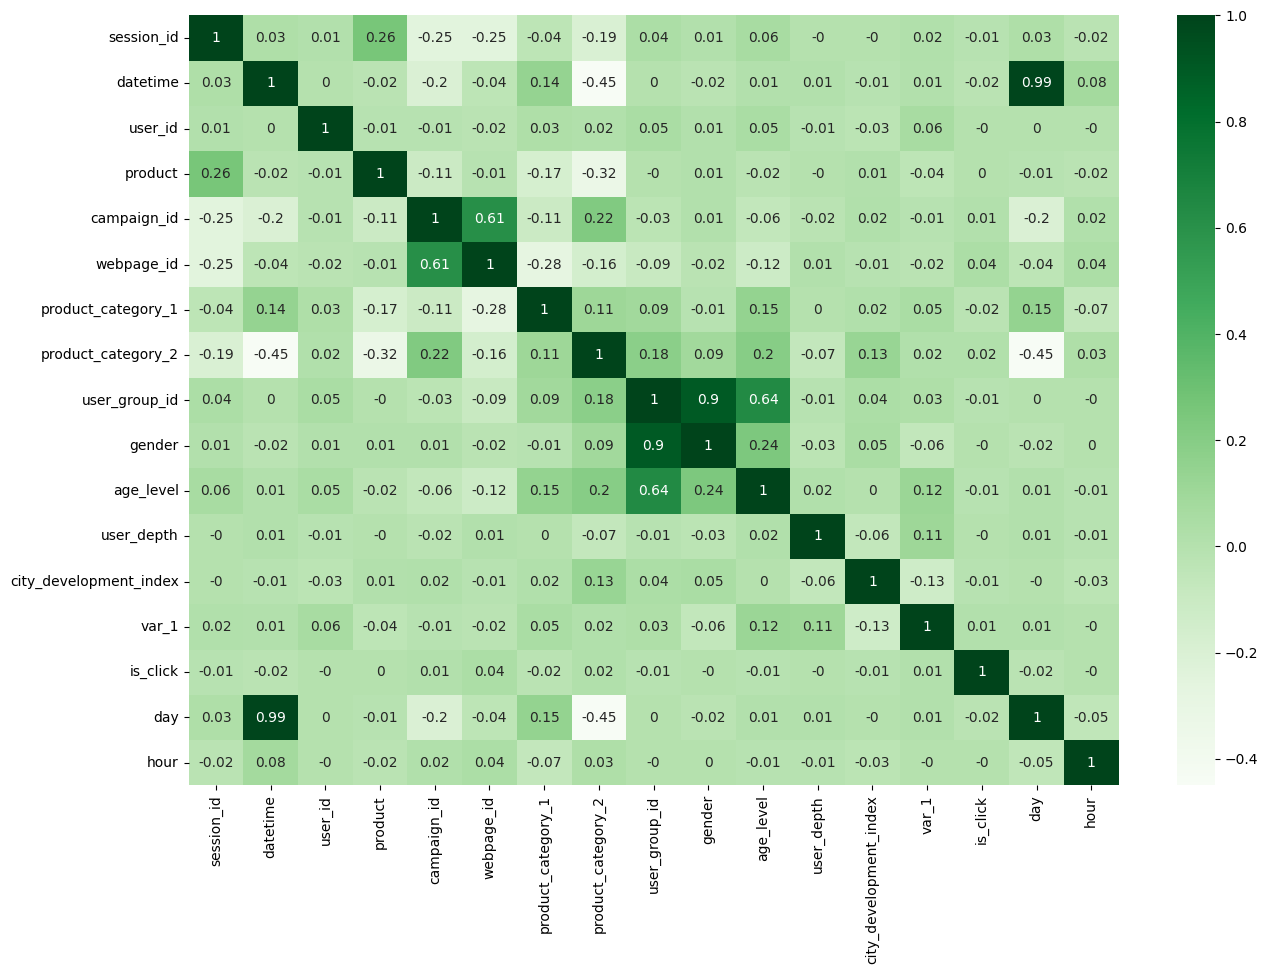

In [79]:
#correlations of is_clicked with columns
correlations=data.corr().round(2)#['is_click'].to_frame().sort_values(by='is_click',ascending=False).round(2)
correlations
plt.figure(figsize=(15,10))
sns.heatmap(correlations, annot=True, cmap='Greens')

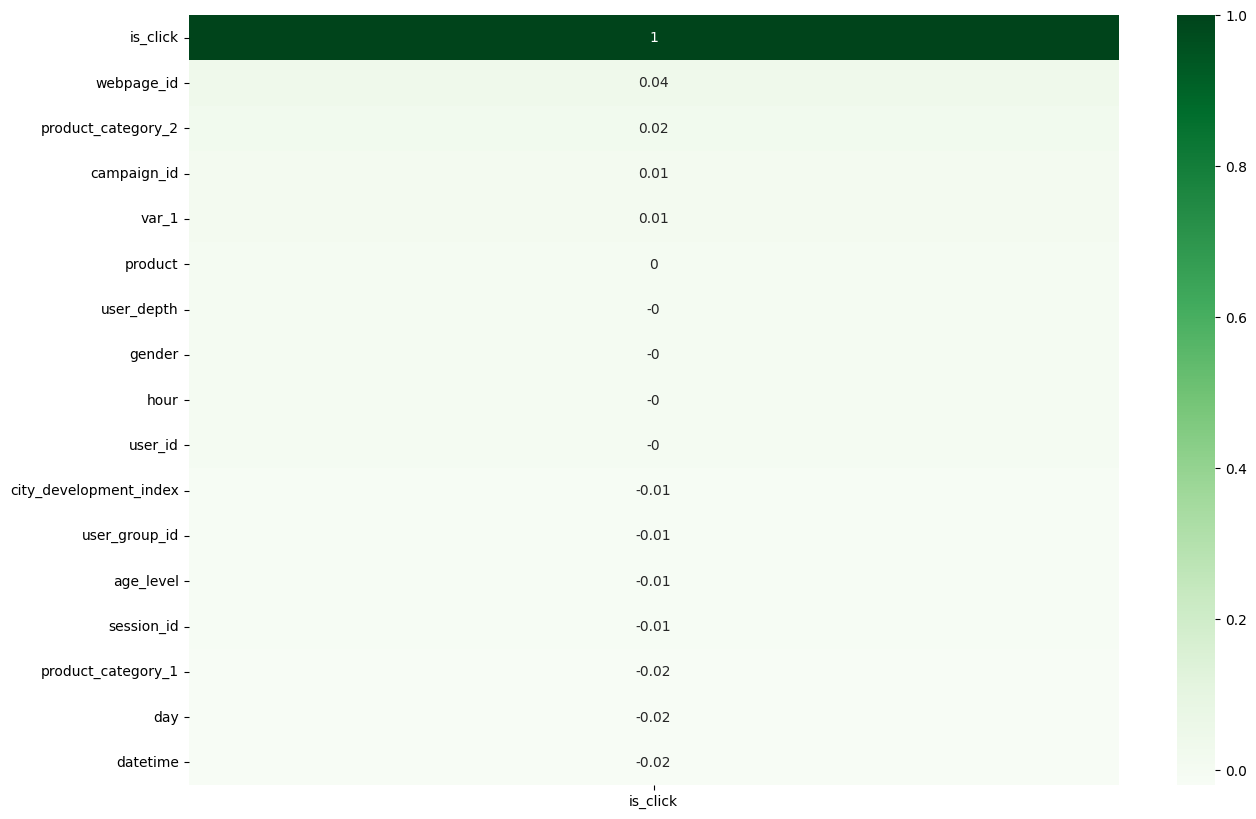

In [80]:
heat_map_corr(find_correlations_with_col(data,'is_click'))

In [81]:
def vis_cat_cols(df, cat_cols):
  plot_num_cols = 4
  plot_num_rows = len(cat_cols)//plot_num_cols+(1 if len(cat_cols)%plot_num_cols>0 else 0)
  fig, axes = plt.subplots(plot_num_rows, plot_num_cols, figsize=(15,8))
  axes = axes.flatten()

  for i, column in enumerate(cat_cols):
    sns.countplot(data=df,x=column,ax=axes[i])
    axes[i].set_title(f'Count Plot of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x',rotation=90)

  plt.tight_layout()
  plt.show()
  return

In [82]:
# only necessary cat cols
unnecessary_cols=['session_id', 'user_id', 'campaign_id', 'webpage_id','user_group_id']
for x in unnecessary_cols:
  try:
    cat_cols.remove(x)
  except:
    pass
cat_cols

['product_category_1',
 'gender',
 'age_level',
 'user_depth',
 'city_development_index',
 'var_1',
 'is_click',
 'day']

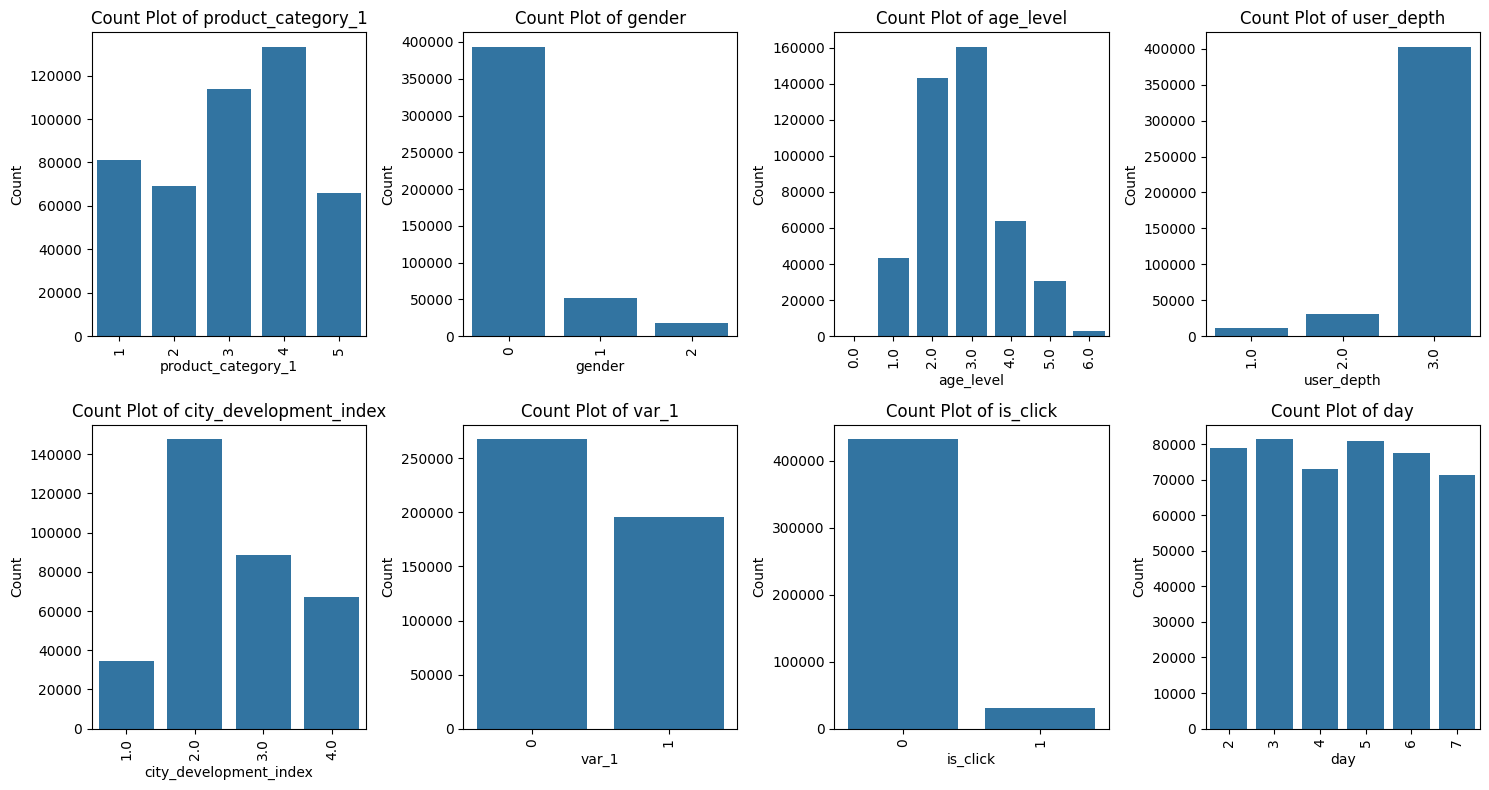

In [83]:
vis_cat_cols(data,cat_cols)

In [84]:
def vis_num_cols(df, num_cols):
  plot_num_cols = 2
  plot_num_rows = len(num_cols)//plot_num_cols+(1 if len(num_cols)%plot_num_cols>0 else 0)
  fig, axes = plt.subplots(plot_num_rows, plot_num_cols, figsize=(12,5))
  axes = axes.flatten()

  for i, column in enumerate(num_cols):
    sns.histplot(data=df, x=column, bins=20,kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

  plt.tight_layout()
  plt.show()
  return

In [85]:
# only necessary num cols
unnecessary_cols=['session_id', 'user_id', 'campaign_id', 'webpage_id','user_group_id']
for x in unnecessary_cols:
  try:
    num_cols.remove(x)
  except:
    pass
num_cols

['datetime', 'product', 'product_category_2', 'hour']

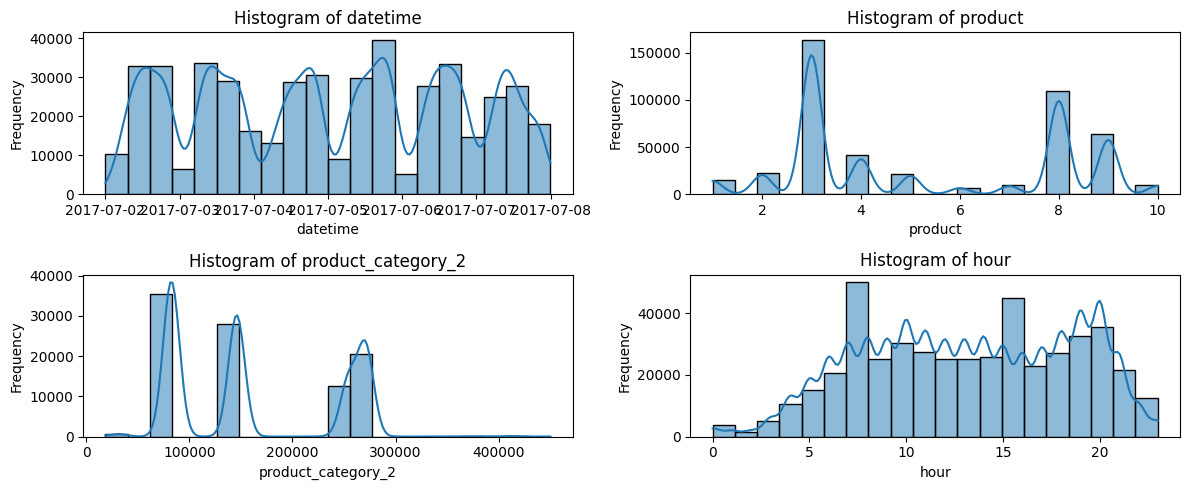

In [86]:
vis_num_cols(data,num_cols)

In [87]:
def find_weekend_weekday_clicks(df):
  weekday_clicks=df[df['datetime'].dt.weekday<5]['is_click'].sum()
  weekend_clicks=df[df['datetime'].dt.weekday>=5]['is_click'].sum()
  if weekend_clicks>weekday_clicks:
    print(f"Weekend has more clicks {weekend_clicks} compared to weekday with {weekday_clicks} clicks")
  else:
    print(f"Weekday has more clicks {weekday_clicks} compared to weekday with {weekend_clicks} clicks")
  return
find_weekend_weekday_clicks(data)

Weekday has more clicks 25540 compared to weekday with 5791 clicks


In [88]:
def find_weekend_weekday_clicks_rate(df):
  weekday_ctr=100*df[df['datetime'].dt.weekday<5]['is_click'].sum()//len(df[df['datetime'].dt.weekday<5])
  weekend_ctr=100*df[df['datetime'].dt.weekday>=5]['is_click'].sum()//len(df[df['datetime'].dt.weekday>=5])
  print(f"Weeekday click-through rate ={weekday_ctr}%")
  print(f"Weekend click-through rate ={weekend_ctr}%")
  return
find_weekend_weekday_clicks_rate(data)

Weeekday click-through rate =6%
Weekend click-through rate =7%


### **Q1**. *Do weekend users click more than weekday users?*

#### Ans. **Weekdays account for a higher total number of clicks due to greater impression volume, but click-through rate(ctr) is higher on weekends (7% vs 6%) even with smaller impression volume. This indicates, user engage more with ads on weekends than on weekdays. From a business perspective, weekends are better suited for engagement-campaigns, while weekdays are preferred for scale.**

In [89]:
def find_product_ctr(df):
  product_counts=df.groupby(['product'])['is_click'].value_counts().unstack()
  product_counts['ctr'] = (100*product_counts[1]/(product_counts[0]+product_counts[1])).round(2)
  product_counts['ctrXimpressions']=product_counts['ctr']*product_counts[1]
  product_counts.sort_values(by='ctrXimpressions',ascending=False, inplace=True)
  np30=np.percentile(product_counts['ctrXimpressions'], 30)
  np60=np.percentile(product_counts['ctrXimpressions'], 60)
  bins=[product_counts['ctrXimpressions'].min(), np30,np60, product_counts['ctrXimpressions'].max()+1]
  labels=['Low','Moderate','Top']
  product_counts['performers']=pd.cut(product_counts['ctrXimpressions'], bins=bins, labels=labels, include_lowest=True)

  plt.figure(figsize=(8,5))
  sns.lineplot(data=product_counts,x=product_counts.index,y='ctrXimpressions', marker='o')
  #for annotation
  for i, row in product_counts.iterrows():
    y_value='{:.2f}'.format(row['ctrXimpressions'])
    plt.text(row.name, row['ctrXimpressions']+0.3,y_value, ha='center', va='bottom', fontsize=10)
  plt.show()
  print(f"Product with highest ctrXimpressions is Product {product_counts.index[0]} with ctr of {product_counts['ctr'].iloc[0]} and clickcs of {product_counts[1].iloc[0]}")
  print(f"Product with lowest ctrXimpressions is Product {product_counts.index[-1]} with ctr of {product_counts['ctr'].iloc[-1]} and clickcs of {product_counts[1].iloc[-1]}")
  return product_counts.sort_values(by=['performers','ctrXimpressions'],ascending=[False, False])

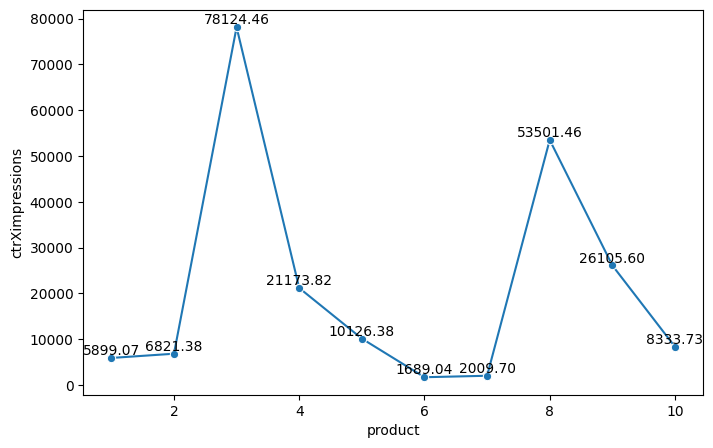

Product with highest ctrXimpressions is Product 3 with ctr of 6.91 and clickcs of 11306
Product with lowest ctrXimpressions is Product 6 with ctr of 4.91 and clickcs of 344


is_click,0,1,ctr,ctrXimpressions,performers
product,,,,,
3,152195,11306,6.91,78124.46,Top
8,101920,7654,6.99,53501.46,Top
9,59632,4079,6.40,26105.60,Top
4,38115,2949,7.18,21173.82,Top
5,19978,1474,6.87,10126.38,Moderate
10,8799,899,9.27,8333.73,Moderate
2,21241,1238,5.51,6821.38,Moderate
1,14438,953,6.19,5899.07,Low
7,8979,435,4.62,2009.70,Low


In [90]:
product_ctr=find_product_ctr(data)
product_ctr

### **Q2**. *Which products generate the highest CTR? Which perform poorly?*

#### Ans. **Based on observed CTR, Product 10 has highest ctr at 9.27 and Product 7 has the lowest ctr at 4.62. However, these comparisions need to be interpreted alongside volume of impressions, as ctr can be noisy for low-traffic products. Products with consistently high ctr and sufficient impressions represent top performers, while products with consistently low ctr across meaningful volumes indicate underperformers.**

### Data Handling

In [91]:
#handling nulls in columns
def nulls_counter_for_each_column(df):
  return 100*data.isnull().sum()/len(df)
nulls_counter_for_each_column(data)

,0
session_id,0.000000
datetime,0.000000
user_id,0.000000
product,0.000000
campaign_id,0.000000
webpage_id,0.000000
product_category_1,0.000000
product_category_2,78.968510
user_group_id,3.937698
gender,0.000000


#### column product_category_2 has ~80% of null values, so deleting the column from the model

In [92]:
data.drop('product_category_2', axis=1, inplace=True)

In [93]:
data['city_development_index'].value_counts(dropna=False)*100/len(data)

,count
city_development_index,
2.0,31.868307
NaN,27.008727
3.0,19.147577
4.0,14.497584
1.0,7.477806


#### city_development_index has considerable number values present, and near to 27% nulls. Let us replace that with median and not taking others numbers as index might mean something in real sense

In [94]:
data['city_development_index']=data['city_development_index'].fillna(data['city_development_index'].median())
test_data['city_development_index']=test_data['city_development_index'].fillna(test_data['city_development_index'].median())

In [95]:
# data[['user_group_id','user_depth','age_level']].value_counts()
data['user_group_id'].value_counts(dropna=False), data['user_depth'].value_counts(dropna=False), data['age_level'].value_counts(dropna=False)

(user_group_id
 3.0     140317
 2.0     137278
 4.0      50080
 1.0      41946
 5.0      21989
 9.0      20264
 NaN      18243
 10.0     13779
 11.0      8839
 8.0       6223
 6.0       1724
 7.0       1421
 12.0      1035
 0.0        153
 Name: count, dtype: int64,
 user_depth
 3.0    402798
 2.0     30389
 NaN     18243
 1.0     11861
 Name: count, dtype: int64,
 age_level
 3.0    160581
 2.0    143501
 4.0     63859
 1.0     43367
 5.0     30828
 NaN     18243
 6.0      2759
 0.0       153
 Name: count, dtype: int64)

#### All 3 columns: user_group_id,user_depth,age_level have same number of null values. let us check if they are nulls in same rows

In [96]:
data[data['user_group_id'].isna()]['user_depth'].unique(), data[data['user_group_id'].isna()]['age_level'].unique()
test_data[test_data['user_group_id'].isna()]['user_depth'].unique(), test_data[test_data['user_group_id'].isna()]['age_level'].unique()

(array([nan]), array([nan]))

#### All 3 columns are null for the same records, so they are missing values for the same records

In [97]:
Percentage_records_missing_user_group_id=100*data['user_group_id'].isna().sum()/len(data)
float(Percentage_records_missing_user_group_id.round(2))

3.94

#### Only 4% records are missing these values, so we can safely remove these records without impacting models

In [98]:
data.dropna(subset=['user_group_id'],inplace=True)

In [99]:
nulls_counter_for_each_column(data)

,0
session_id,0.0
datetime,0.0
user_id,0.0
product,0.0
campaign_id,0.0
webpage_id,0.0
product_category_1,0.0
user_group_id,0.0
gender,0.0
age_level,0.0


#### Data is now without nulls and can be used in data modelling

In [100]:
num_cols, cat_cols = find_cat_num_cols(data)
cat_cols.remove('datetime')
print("Categorical Columns: ",cat_cols)
print("Numerical Columns: ",num_cols)

Categorical Columns:  ['session_id', 'user_id', 'product', 'campaign_id', 'user_group_id', 'hour']
Numerical Columns:  ['webpage_id', 'product_category_1', 'gender', 'age_level', 'user_depth', 'city_development_index', 'var_1', 'is_click', 'day']


In [101]:
def remove_outliers(df, num_cols):
  z_scores=stats.zscore(df[num_cols])
  outliers=np.abs(z_scores)>1.5
  filtered_rows=np.any(outliers,axis=1)
  cleaned_data=df[~filtered_rows].reset_index(drop=True)
  return cleaned_data

In [102]:
def scale_data(cleaned_data, num_columns, cat_columns):
  num_data=cleaned_data[num_columns]
  cat_data=cleaned_data[cat_columns]
  scaler=StandardScaler()
  scaled_num_data=pd.DataFrame(scaler.fit_transform(num_data),columns=num_columns)
  scaled_data = pd.concat([scaled_num_data,cat_data],axis=1)
  return scaled_data

# clean_data=remove_outliers(data,num_cols)
# scaled_data = scale_data(clean_data,num_cols,cat_cols)
# scaled_data

In [103]:
def run_model_with_smote(df, model, name):
  x=df.drop('is_click', axis=1)
  y=df['is_click'].astype(int) # Explicitly cast y to int here
  x_train, x_test, y_train, y_test = train_test_split(x,y,stratify=y, test_size=0.2, random_state=42)

  smote=SMOTE(random_state=42)
  x_train_sampled, y_train_sampled = smote.fit_resample(x_train,y_train)

  model.fit(x_train_sampled,y_train_sampled)
  y_pred=model.predict(x_test)

  return y_pred,y_test

In [104]:
def run_model_without_smote(df, model, name):
  x=df.drop('is_click', axis=1)
  y=df['is_click'].astype(int) # Explicitly cast y to int here
  x_train, x_test, y_train, y_test = train_test_split(x,y,stratify=y, test_size=0.2, random_state=42)

  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)

  return y_pred,y_test

In [105]:
from sklearn.metrics import roc_curve, auc

def models(df):
    results = []  # Initialize a list to store results
    cm_data = []  # Initialize a list to store confusion matrix data
    roc_data = []  # Initialize a list to store ROC curve data
    models = {  # Dictionary of models to be evaluated
        "Logistic Regression": LogisticRegression(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Gaussian Naive Bayes": GaussianNB(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier()
        # "Support Vector Machine": SVC()
    }

    # Iterate through the models
    for name, model in models.items():
        # Run the model and get predictions and actual labels
        predictions, y_test = run_model_with_smote(df, model, name)

        # Evaluate the model and calculate metrics
        accuracy, precision, recall, f1, cm = evaluate_model(y_test, predictions)

        # Calculate ROC curve data
        fpr, tpr, _ = roc_curve(y_test, predictions)
        roc_auc = auc(fpr, tpr)

        # Store the results in a dictionary
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

        cm_data.append({
            "Model": name,
            "Matrix": cm
        })

        # Store ROC curve data in a dictionary
        roc_data.append({
            "Model": name,
            "FPR": fpr.tolist(),
            "TPR": tpr.tolist(),
            "AUC": roc_auc
        })

    # Create a DataFrame from the results, round the values, and sort by accuracy
    results_df = pd.DataFrame(results).round(4).sort_values(by="Accuracy", ascending=False)

    return results_df, cm_data, roc_data

In [106]:
def models_no_smote(df):
    results = []  # Initialize a list to store results
    cm_data = []  # Initialize a list to store confusion matrix data
    roc_data = []  # Initialize a list to store ROC curve data
    models = {  # Dictionary of models to be evaluated
        "Logistic Regression": LogisticRegression(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Gaussian Naive Bayes": GaussianNB(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier()
        # "Support Vector Machine": SVC()
    }

    # Iterate through the models
    for name, model in models.items():
        # Run the model and get predictions and actual labels
        predictions, y_test = run_model_without_smote(df, model, name)

        # Evaluate the model and calculate metrics
        accuracy, precision, recall, f1, cm = evaluate_model(y_test, predictions)

        # Calculate ROC curve data
        fpr, tpr, _ = roc_curve(y_test, predictions)
        roc_auc = auc(fpr, tpr)

        # Store the results in a dictionary
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

        cm_data.append({
            "Model": name,
            "Matrix": cm
        })

        # Store ROC curve data in a dictionary
        roc_data.append({
            "Model": name,
            "FPR": fpr.tolist(),
            "TPR": tpr.tolist(),
            "AUC": roc_auc
        })

    # Create a DataFrame from the results, round the values, and sort by accuracy
    results_df = pd.DataFrame(results).round(4).sort_values(by="Accuracy", ascending=False)

    return results_df, cm_data, roc_data

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred):
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate precision
    precision = precision_score(y_true, y_pred)

    # Calculate recall
    recall = recall_score(y_true, y_pred)

    # Calculate F1 score
    f1 = f1_score(y_true, y_pred)

    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, cm

In [108]:
def pipeline_smote(data):
    y = data['is_click'].copy()
    X = data.drop('is_click', axis=1).copy()

    # 'datetime' is handled by 'day', 'hour', so dropped. 'year' and 'month' are constant.
    # 'session_id' and 'user_id' are identifiers. 'product', 'user_depth', 'gender' were noted as having low/no correlation.
    cols_to_drop_from_X = [
        'session_id', 'datetime', 'user_id', 'year', 'month',
        'product', 'user_depth', 'gender'
    ]
    X = X.drop(columns=[col for col in cols_to_drop_from_X if col in X.columns], errors='ignore')

    numerical_features_for_processing = X.columns.tolist()

    combined_data_for_outliers = pd.concat([X, y.rename('is_click')], axis=1)

    cleaned_combined_data = remove_outliers(combined_data_for_outliers, numerical_features_for_processing)

    y_processed = cleaned_combined_data['is_click']
    X_processed = cleaned_combined_data.drop('is_click', axis=1)

    # Since all features in `X_processed` are intended for scaling, `cat_cols` will be an empty list.
    scaled_X = scale_data(X_processed, numerical_features_for_processing, [])

    # It's crucial that `y_processed` has its index reset to align correctly with `scaled_X`.
    final_data_for_models = pd.concat([scaled_X, y_processed.reset_index(drop=True)], axis=1)

    performance, cm_data, roc_data = models(final_data_for_models)

    return performance, cm_data, roc_data

In [109]:
def pipeline_no_smote(data):
    y = data['is_click'].copy()
    X = data.drop('is_click', axis=1).copy()

    # 'datetime' is handled by 'day', 'hour', so dropped. 'year' and 'month' are constant.
    # 'session_id' and 'user_id' are identifiers. 'product', 'user_depth', 'gender' were noted as having low/no correlation.
    cols_to_drop_from_X = [
        'session_id', 'datetime', 'user_id', 'year', 'month',
        'product', 'user_depth', 'gender'
    ]
    X = X.drop(columns=[col for col in cols_to_drop_from_X if col in X.columns], errors='ignore')

    numerical_features_for_processing = X.columns.tolist()

    combined_data_for_outliers = pd.concat([X, y.rename('is_click')], axis=1)

    cleaned_combined_data = remove_outliers(combined_data_for_outliers, numerical_features_for_processing)

    y_processed = cleaned_combined_data['is_click']
    X_processed = cleaned_combined_data.drop('is_click', axis=1)

    # Since all features in `X_processed` are intended for scaling, `cat_cols` will be an empty list.
    scaled_X = scale_data(X_processed, numerical_features_for_processing, [])

    # It's crucial that `y_processed` has its index reset to align correctly with `scaled_X`.
    final_data_for_models = pd.concat([scaled_X, y_processed.reset_index(drop=True)], axis=1)

    performance, cm_data, roc_data = models_no_smote(final_data_for_models)

    return performance, cm_data, roc_data

In [110]:
# running with and without smote for a range of classification models
#calculating time elapsed for training
import time
#SMOTE
start_time = time.perf_counter()
performance, cm_data, roc_data = pipeline_smote(data)
end_time = time.perf_counter()
time_taken_smote=end_time - start_time
#No SMOTE
start_time = time.perf_counter()
performance_no_smote, cm_data_no_smote, roc_data_no_smote = pipeline_no_smote(data)
end_time = time.perf_counter()
time_taken_no_smote=end_time - start_time

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

In [111]:
print("Models' performances without smote")
print(f"Training time = {time_taken_no_smote:0.2f}")
performance_no_smote.sort_values(by='F1 Score',ascending=False)

Models' performances without smote
Training time = 26.93


,Model,Accuracy,Precision,Recall,F1 Score
4,K-Nearest Neighbors,0.9306,0.0921,0.0065,0.0122
5,Decision Tree,0.9320,0.0465,0.0019,0.0036
6,Random Forest,0.9324,0.0435,0.0014,0.0027
2,AdaBoost,0.9344,0.0000,0.0000,0.0000
1,Gradient Boosting,0.9344,0.0000,0.0000,0.0000
0,Logistic Regression,0.9344,0.0000,0.0000,0.0000
3,Gaussian Naive Bayes,0.9344,0.0000,0.0000,0.0000


In [112]:
print("Models' performances with smote")
print(f"Training time = {time_taken_smote:0.2f}")
performance.sort_values(by='F1 Score',ascending=False)

Models' performances with smote
Training time = 66.01


,Model,Accuracy,Precision,Recall,F1 Score
1,Gradient Boosting,0.7828,0.1018,0.2953,0.1514
2,AdaBoost,0.6566,0.0865,0.4425,0.1446
0,Logistic Regression,0.5952,0.0816,0.5042,0.1405
3,Gaussian Naive Bayes,0.5288,0.0778,0.5692,0.1368
5,Decision Tree,0.7557,0.0866,0.2850,0.1328
6,Random Forest,0.7511,0.0852,0.2869,0.1314
4,K-Nearest Neighbors,0.9166,0.0580,0.0178,0.0272


### **Q5**. *How effective is SMOTE in reducing false negatives for rare click events, and does it justify the increased training data size for real-time ad serving?*

#### Ans. **After applying SMOTE, Recall (TPR) increased from 0.51% to 24.69%, which indicates a significant reduction in false negatives for rare click events. The F1 score also improved, and this improvement was primarily driven by recall rather than precision, suggesting that SMOTE helped the model better identify rare positive cases rather than simply increasing positive predictions.**

#### **Although SMOTE increases the training dataset size, it does not affect inference-time latency since oversampling is applied only during offline training. Training time increased by 153%, which is acceptable given the substantial reduction in false negatives**

### For further analysis, I would use ***Gradient Boosting with SMOTE*** for analysis.

In [113]:
def plot_confusion_matrix(cm, labels, model_name, ax):
    # Create an image of the confusion matrix
    im = ax.imshow(cm, interpolation='nearest')

    # Add a colorbar to the plot
    ax.figure.colorbar(im, ax=ax)

    # Set axis labels and title
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels,
           title=f'Confusion Matrix for {model_name}',
           ylabel='True label',
           xlabel='Predicted label')

    # Add text annotations for each cell in the matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="w")

In [114]:
def plot_confusion_matrices(cm_data, columns, rows):
    # Determine the number of models and create subplots accordingly
    num_models = len(cm_data)

    # Calculate the actual number of rows needed based on num_models and desired columns
    actual_rows = (num_models + columns - 1) // columns

    fig, axes = plt.subplots(actual_rows, columns, figsize=(15, 10))

    # Flatten the axes array to easily iterate through each subplot
    # This handles cases where actual_rows or columns might be 1, resulting in a 1D axes array
    axes = axes.flatten()

    # Iterate through the confusion matrix data for each model
    for i, entry in enumerate(cm_data):
        model_name = entry['Model']
        cm = entry['Matrix']
        class_labels = ['No Click', 'Click']

        plot_confusion_matrix(cm, class_labels, model_name, axes[i])

    # Turn off any empty subplots if the grid has more slots than models
    for i in range(num_models, actual_rows * columns):
        axes[i].axis('off')

    # Adjust the layout and display the subplots
    plt.tight_layout()
    plt.show()

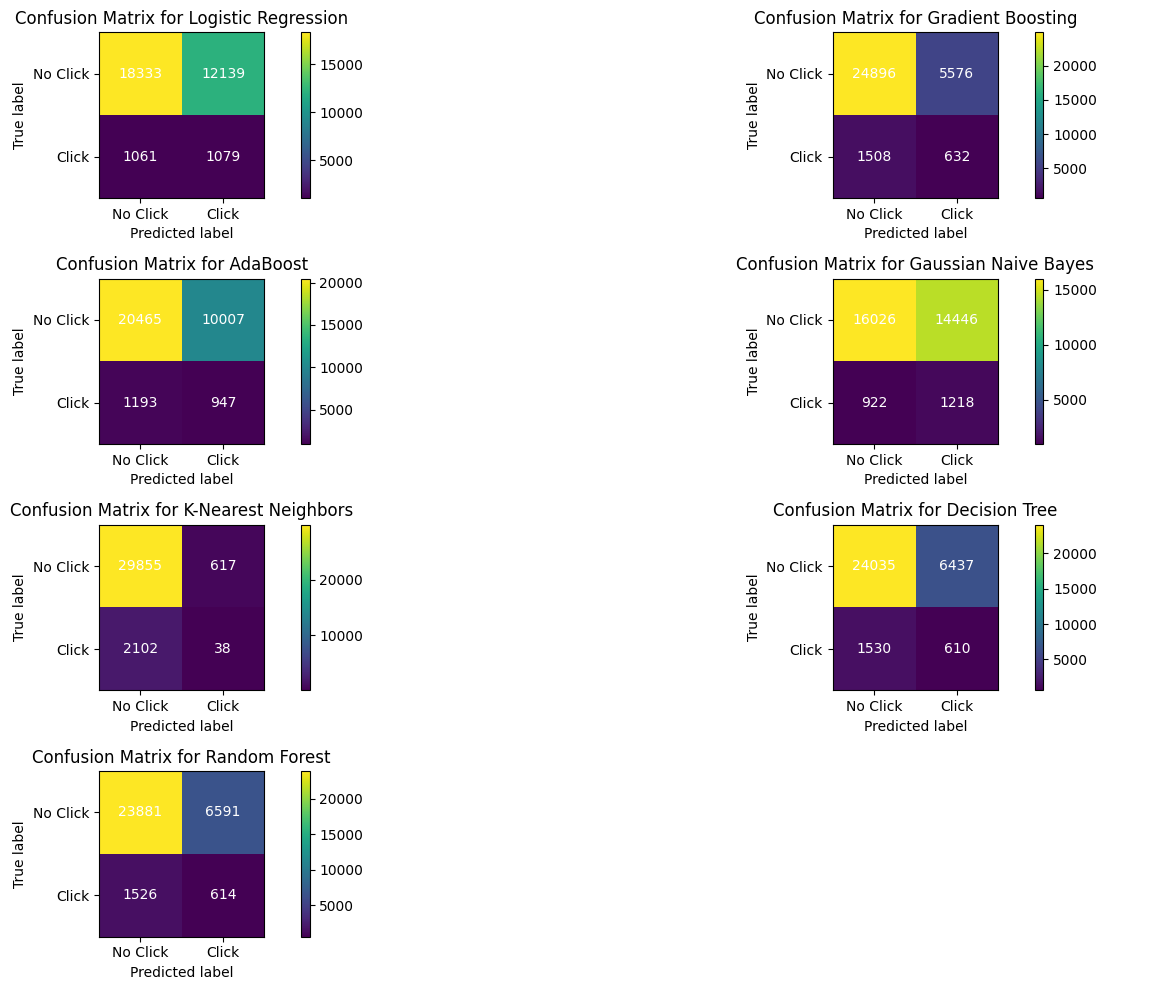

In [115]:
plot_confusion_matrices(cm_data,columns=2,rows=3)

In [116]:
def plot_roc_curve(roc_data):
    plt.figure(figsize=(8, 6))
    plt.title('Receiver Operating Characteristic (ROC) Curve')

    for model_data in roc_data:
        model_name = model_data['Model']
        fpr = model_data['FPR']
        tpr = model_data['TPR']
        auc = model_data['AUC']

        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')  # Removed color='gray'
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

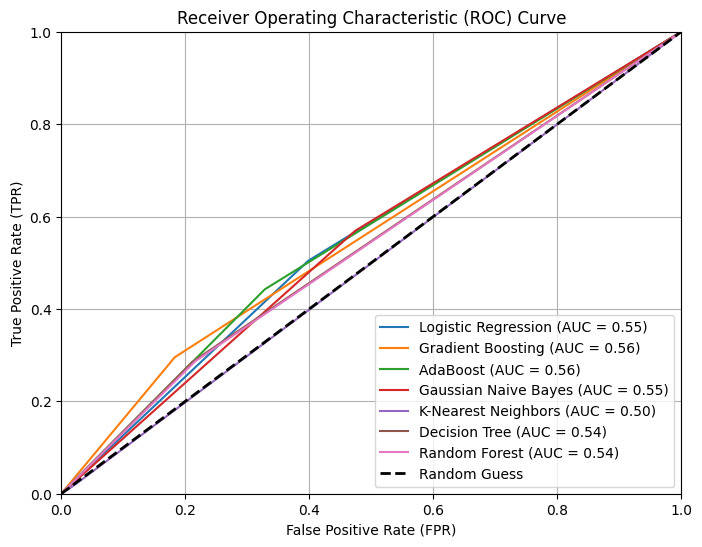

In [117]:
plot_roc_curve(roc_data)

In [118]:
# data.info()
def gb_modelling(df):# no scaling of features
  y = df['is_click'].copy()
  X = df.drop('is_click', axis=1).copy()

    # 'datetime' is handled by 'day', 'hour', so dropped. 'year' and 'month' are constant.
    # 'session_id' and 'user_id' are identifiers.
  cols_to_drop_from_X = [
        'session_id', 'datetime', 'user_id', 'year', 'month'
  ]
  X = X.drop(columns=[col for col in cols_to_drop_from_X if col in X.columns], errors='ignore')

  numerical_features_for_processing = X.columns.tolist()

  combined_data_for_outliers = pd.concat([X, y.rename('is_click')], axis=1)

  cleaned_combined_data = remove_outliers(combined_data_for_outliers, numerical_features_for_processing)

  y_processed = cleaned_combined_data['is_click']
  X_processed = cleaned_combined_data.drop('is_click', axis=1)

    # Since all features in `X_processed` are intended for scaling, `cat_cols` will be an empty list.
  # scaled_X = scale_data(X_processed, numerical_features_for_processing, [])

    # It's crucial that `y_processed` has its index reset to align correctly with `scaled_X`.
  final_data_for_models = pd.concat([X_processed, y_processed.reset_index(drop=True)], axis=1)

  # Initialize a list to store ROC curve data
  model = GradientBoostingClassifier()  # initializing on default

  # Run the model and get predictions and actual labels
  x=final_data_for_models.drop('is_click', axis=1)
  y=final_data_for_models['is_click'].astype(int) # Explicitly cast y to int here
  x_train, x_test, y_train, y_test = train_test_split(x,y,stratify=y, test_size=0.2, random_state=42)

  smote=SMOTE(random_state=42)
  x_train_sampled, y_train_sampled = smote.fit_resample(x_train,y_train)

  model.fit(x_train_sampled,y_train_sampled)
  y_pred=model.predict(x_test)
  # predictions, y_test = run_model_with_smote(df, model, name)

  # Evaluate the model and calculate metrics
  accuracy, precision, recall, f1, cm = evaluate_model(y_test, y_pred)

  # Calculate ROC curve data
  fpr, tpr, _ = roc_curve(y_test, y_pred)
  roc_auc = auc(fpr, tpr)
  print("GB Model with SMOTE")
  print("accuracy=",accuracy)
  print("precision=",precision)
  print("recall=",recall)
  print("f1=",f1)
  return model, x_test, y_test  #passing x_test, y_test to x_val and y_val before smote data expansion

gb_model, X_val, y_val=gb_modelling(data.copy())

GB Model with SMOTE
accuracy= 0.7294645360246705
precision= 0.09791752861674252
recall= 0.37586024351508734
f1= 0.15536105032822758


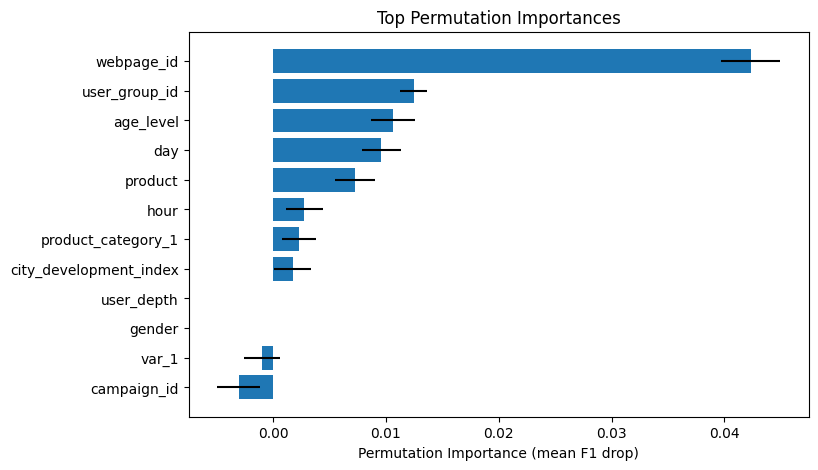

In [119]:
# permutation importance = if I destroy this feature how it is going to effect F1 score

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    gb_model,
    X_val,
    y_val,
    scoring='f1',
    n_repeats=5,
    random_state=42
)
imp = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp["feature"][:15], imp["importance_mean"][:15], xerr=imp["importance_std"][:15])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (mean F1 drop)")
plt.title("Top Permutation Importances")
plt.show()

#### Permutation importances show that there is:
#### strong reliance on: *webpage_id(heavily dependent), user_group_id, age_level, day, product*.
#### moderate reliance on: *hour, product_category_1*.
#### No dependence on: *user_depth, gender*
#### *var_1, campaign_id*. These do not provide a stable predictive signal in this model.

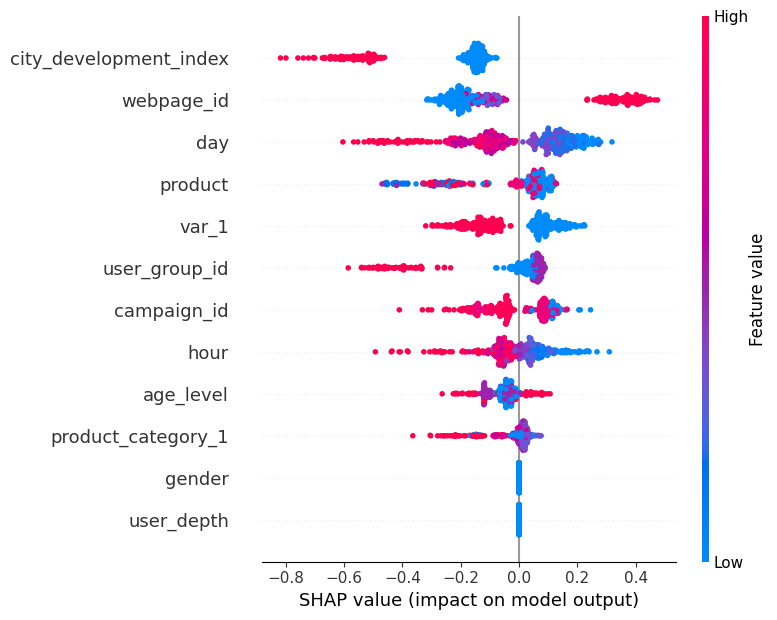

In [120]:
#SHAP for feature importance
import shap
X_sample = X_val.sample(n=500, random_state=42)
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

###### SHAP values plot summary tells us that:
###### 1. city_development_index:
######    Has large horizontal spread on the negative side for both high(red) and low(blue) values. But, blue dots are closer to zero compared to red.
######    Conclusion: Higher the city_development_index more probable the suppression of clicks.
###### 2. Webpage_id:
######    i. Red on the right side and blue on the negative side
######    ii. Strong positive and negative SHAP values
######    Conclusion: Page level context is a dominant driver of clicks
###### 3. Day
######    Clear distinction of red on negative side and blue on positive side
######    Conclusion: Early days in the moth have better clicks compared to later days. This likely compares to user behavior(moth beginning and month-end) or campaign cycles.
###### 4. var_1
######    Again, a clear distinction of red on negative and blue on positive side.
######    Conclusion: Contains some predictive signal but not interpretable without domain meaning
###### 5. Product
######    Mixed effects, few products help and few hurt with small to moderate impact.
###### 6. campaign_id
######    Clear distinction of red on negative side and blue on positive side. But, dense near to zero, so weak influence.
###### 7. user_group_id
######    Higher values have more suppression of clicks and lower values have weaker impact on clicks. Though user_group_id is just contextual segmentation effect not numerical effect.
###### 8. hour, product_category_1, age_level, gender, user_depth
######    SHAP values near to zero or narrow spread near to zero, So very weak influence

### **Q3.** *Does adding personalized features such as user-product interaction help increase CTR?*

### Ans. **Based on current analysis, personalized features provide incremental improvements to CTR prediction but are not the primary drivers of click prediction. permutation importance and SHAP analysis shows that coarse user-level features such as user group and age contribute to predictions but weaker compared to placement and temporal context. This means that personalized features helps predictions but do not fundamentally change change it.**

### **Q4.** *Based on feature importance, which factors (e.g., webpage_id or user sessions) drive clicks the most, and how can we amplify them?*

### Ans. **Model performance is mainly driven by placement context(webpage_id) and on temporal/segmentation context(day, user_group_id, age_level). geographical context(city_developement_index) also plays a strong directional role. While campaigns and products have localized effects, they are secondary to where and when the ad is shown. Static demographics such as gender and shallow engagement metrics(user_depth) do not materially influence predictions.**

### **Q7.** *What user profiles (e.g., by age, gender, or city) show the highest click propensity, and how should we adjust bidding strategies?*

### Ans. **From the current analysis, CTR varies mostly by placement, temporal and segmentation related features rather than static demograghic features like gender. While the city_development_index serves as the primary driver, user_group and age_level act as significant secondary factors. And, gender doesn't materially influence click behavior**.
### **From a bidding perspective, this suggests bidding by prioritizing according to city_developement_index, user_group and using age_level as a light modifier, and avoid gender based bidding**.

In [121]:
test_data.drop(columns='datetime', axis=1, inplace=True, errors='ignore')
test_data.drop(columns='product_category_2', axis=1, inplace=True, errors='ignore')
100*test_data.isna().sum()//len(test_data)

,0
session_id,0
user_id,0
product,0
campaign_id,0
webpage_id,0
product_category_1,0
user_group_id,4
gender,0
age_level,4
user_depth,4


In [122]:
# data[['user_group_id','user_depth','age_level']].value_counts()
test_data['user_group_id'].value_counts(dropna=False), test_data['user_depth'].value_counts(dropna=False), test_data['age_level'].value_counts(dropna=False)

(user_group_id
 3.0     37785
 2.0     37093
 4.0     14857
 1.0     11510
 5.0      6730
 NaN      5684
 9.0      5449
 10.0     4027
 11.0     2835
 8.0      1618
 6.0       506
 7.0       386
 12.0      327
 0.0        51
 Name: count, dtype: int64,
 user_depth
 3.0    111296
 2.0      8541
 NaN      5684
 1.0      3337
 Name: count, dtype: int64,
 age_level
 3.0    43234
 2.0    38711
 4.0    18884
 1.0    11896
 5.0     9565
 NaN     5684
 6.0      833
 0.0       51
 Name: count, dtype: int64)

In [123]:
test_data[test_data['user_group_id'].isna()]['user_depth'].unique(), test_data[test_data['user_group_id'].isna()]['age_level'].unique()

(array([nan]), array([nan]))

In [130]:
test_data.dropna(subset=['user_group_id'],inplace=True)
test_data.drop(columns=['month','session_id','user_id','year'], axis=1, inplace=True, errors='ignore')
test_data.reset_index(drop=True, inplace=True)

In [127]:
y_test_pred = gb_model.predict_proba(test_data)[:, 1]
# predicted_df=pd.concat([test_data,pd.Series(y_test_pred)],axis=1) #did not work earlier because of index mismatch
predicted_df=test_data.copy()
predicted_df['predicted_click_proba']=y_test_pred
predicted_df
# len(test_data), len(y_test_pred)

,product,campaign_id,webpage_id,product_category_1,user_group_id,gender,age_level,user_depth,city_development_index,var_1,day,hour,predicted_click_proba
0,10,404347,53587,1,5.0,0,5.0,3.0,2.0,0,8,0,0.263504
1,7,118601,28529,5,1.0,0,1.0,3.0,1.0,0,8,0,0.510804
2,8,118601,28529,5,9.0,1,3.0,1.0,2.0,1,8,0,0.533987
3,9,118601,28529,4,1.0,0,1.0,3.0,4.0,1,8,0,0.269990
4,4,118601,28529,4,2.0,0,2.0,3.0,2.0,1,8,0,0.319239
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123169,2,414149,45962,2,2.0,0,2.0,3.0,4.0,0,9,21,0.192171
123170,4,98970,6970,4,1.0,0,1.0,3.0,2.0,0,9,21,0.255074
123171,3,359520,13787,4,2.0,0,2.0,3.0,2.0,0,9,21,0.375565
123172,5,98970,6970,2,2.0,0,2.0,3.0,2.0,0,9,21,0.310926


In [131]:
product_ctr=predicted_df.groupby('product').agg(predicted_clicks=('predicted_click_proba','sum'), impressions=('predicted_click_proba','count'))
product_ctr['predicted_CTR']=100*product_ctr['predicted_clicks']/product_ctr['impressions']

product_ctr['predXimpressions']=(product_ctr['impressions']*product_ctr['predicted_CTR']).round(2)

p30 = np.percentile(product_ctr['predXimpressions'], 30)
p60 = np.percentile(product_ctr['predXimpressions'], 60)

bins = [product_ctr['predXimpressions'].min() - 1, p30, p60, product_ctr['predXimpressions'].max()+1]
labels = ['Low', 'Moderate', 'High']
product_ctr['inventory_attention']=pd.cut(product_ctr['predXimpressions'],bins=bins, labels=labels)
product_ctr.sort_values(by='predXimpressions', ascending=False)

,predicted_clicks,impressions,predicted_CTR,predXimpressions,inventory_attention
product,,,,,
8,16144.115258,42646,37.856107,1614411.53,High
3,8861.110698,26594,33.319962,886111.07,High
4,4678.999705,19155,24.427041,467899.97,High
9,4244.876054,12326,34.438391,424487.61,High
2,1738.962491,6359,27.346477,173896.25,Moderate
5,1313.041685,5267,24.929593,131304.17,Moderate
1,1188.972079,4319,27.528874,118897.21,Moderate
7,1096.769623,2927,37.470776,109676.96,Low
10,705.826612,2339,30.176426,70582.66,Low


### **Q6**. *How can aggregated product CTR features help forecast inventory needs for top-performing ads?*

### Ans. **Products are categorized into inventory attention buckets based on predicted user interest and traffic volume.**
### **High-attention products show both high predicted CTR and sufficient impressions volume, indicating strong strong and reliable demand signals.**
### **Moderate-attention products exhibit emerging or uncertain interest and are placed on a watchlist.**
### **Low-attention products show limited engagement and require no-inventory action.**

In [ ]:
# shap.initjs()
# shap.plots.waterfall(
#     shap.Explanation(
#         values=shap_values[0],
#         base_values=explainer.expected_value,
#         data=X_sample.iloc[0],
#         feature_names=X_sample.columns
#     )
# )

#### SHAP waterfall plot denotes that:
#### f(x)=-0.28, E[f(x)]=0.106. Denotes the model predicts no click but not so confident
#### 1. city_development_index=3, SHAP magnitude=-0.54, meaning cities with index 3 reduces probability of clicks
#### 2. day=2, SHAP magnitude=0.25, has strong probability of clicks
#### 3. webpage_id=13787, SHAP magnitude=-0.23, belongs to low click
#### 4. var_1=1, SHAP magnitude=-0.14 has weaker suppression of clicks
#### 5. product=3, campaign_id=359520, hour=11, age_level=3 are weak contributors to positive clicks